In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('tram-tracks.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:")
print(df.head())
print("\nInfo:")
print(df.info())

Shape: (645, 4)
Columns: ['Geo Point', 'Geo Shape', 'descriptio', 'name']

Head:
                                 Geo Point  \
0    -37.81532421856633, 144.9594549143138   
1  -37.801184239771814, 144.95678321621645   
2   -37.81356919030969, 144.96549422218388   
3    -37.79239484832826, 144.9683645204509   
4      -37.837723207583, 144.9819027809533   

                                           Geo Shape  \
0  {"coordinates": [[[[144.958358092682, -37.8156...   
1  {"coordinates": [[[[144.956816503317, -37.8011...   
2  {"coordinates": [[[[144.965484540487, -37.8136...   
3  {"coordinates": [[[[144.968300450872, -37.7925...   
4  {"coordinates": [[[[144.981870747712, -37.8376...   

                                          descriptio    name  
0  <center><table><tr><th colspan='2' align='cent...  kml_14  
1  <center><table><tr><th colspan='2' align='cent...  kml_19  
2  <center><table><tr><th colspan='2' align='cent...  kml_21  
3  <center><table><tr><th colspan='2' align='cent... 

In [4]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv('tram-tracks.csv')

In [6]:
def extract_polygon_x_y(geo_shape_str):
    try:
        geo_dict = json.loads(geo_shape_str)
        if geo_dict['type'] == 'MultiPolygon':
            # Extracting first polygon for simplicity in visualization
            coords = geo_dict['coordinates'][0][0]
            xs = [pt[0] for pt in coords]
            ys = [pt[1] for pt in coords]
            return xs, ys
    except:
        pass
    return [], []

plt.figure(figsize=(10, 8))
valid_shapes = 0

for idx, row in df.iterrows():
    xs, ys = extract_polygon_x_y(row['Geo Shape'])
    if xs and ys:
        plt.plot(xs, ys, color='blue', alpha=0.5, linewidth=1)
        valid_shapes += 1

plt.title('EDA: Visualization of Melbourne Tram Tracks')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('tram_tracks_eda.png', bbox_inches='tight')
plt.close()

print(f"Plotted {valid_shapes} tram track segments.")

Plotted 645 tram track segments.


In [7]:
pip install pandas geopandas shapely matplotlib folium


   ---------------------------------------- 0/3 [xyzservices]
   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   ---------------------------------------- 3/3 [folium]

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import json
from shapely.geometry import shape

In [9]:
df_trams = pd.read_csv('tram-tracks.csv')

In [10]:
# Parsing the GeoJSON string in the 'Geo Shape' column into actual Shapely geometries
def parse_geom(geojson_str):
    try:
        geo_dict = json.loads(geojson_str)
        return shape(geo_dict)
    except:
        return None

df_trams['geometry'] = df_trams['Geo Shape'].apply(parse_geom)

In [11]:
# Creating the GeoDataFrame and setting the standard GPS coordinate reference system (WGS84)
gdf_trams = gpd.GeoDataFrame(df_trams, geometry='geometry')
gdf_trams.set_crs(epsg=4326, inplace=True)

,Geo Point,Geo Shape,descriptio,name,geometry
0,"-37.81532421856633, 144.9594549143138","{""coordinates"": [[[[144.958358092682, -37.8156...",<center><table><tr><th colspan='2' align='cent...,kml_14,"MULTIPOLYGON (((144.95836 -37.81561, 144.95924..."
1,"-37.801184239771814, 144.95678321621645","{""coordinates"": [[[[144.956816503317, -37.8011...",<center><table><tr><th colspan='2' align='cent...,kml_19,"MULTIPOLYGON (((144.95682 -37.80111, 144.95682..."
2,"-37.81356919030969, 144.96549422218388","{""coordinates"": [[[[144.965484540487, -37.8136...",<center><table><tr><th colspan='2' align='cent...,kml_21,"MULTIPOLYGON (((144.96548 -37.8136, 144.96546 ..."
3,"-37.79239484832826, 144.9683645204509","{""coordinates"": [[[[144.968300450872, -37.7925...",<center><table><tr><th colspan='2' align='cent...,kml_42,"MULTIPOLYGON (((144.9683 -37.79259, 144.96834 ..."
4,"-37.837723207583, 144.9819027809533","{""coordinates"": [[[[144.981870747712, -37.8376...",<center><table><tr><th colspan='2' align='cent...,kml_63,"MULTIPOLYGON (((144.98187 -37.83764, 144.98187..."
...,...,...,...,...,...
640,"-37.7957828377791, 144.94674208879394","{""coordinates"": [[[[144.94662423339, -37.79629...",<center><table><tr><th colspan='2' align='cent...,kml_469,"MULTIPOLYGON (((144.94662 -37.79629, 144.94669..."
641,"-37.80640188675552, 144.96066661986535","{""coordinates"": [[[[144.960102753754, -37.8063...",<center><table><tr><th colspan='2' align='cent...,kml_557,"MULTIPOLYGON (((144.9601 -37.80637, 144.96011 ..."
642,"-37.81693262845701, 144.96158670873507","{""coordinates"": [[[[144.961758833015, -37.8169...",<center><table><tr><th colspan='2' align='cent...,kml_550,"MULTIPOLYGON (((144.96176 -37.81691, 144.9616 ..."
643,"-37.82034639542803, 144.95755045350455","{""coordinates"": [[[[144.957720359875, -37.8203...",<center><table><tr><th colspan='2' align='cent...,kml_603,"MULTIPOLYGON (((144.95772 -37.82032, 144.9574 ..."


In [12]:
# Projecting to a local metric CRS (EPSG:7899 for Victoria) so we can measure in meters, not degrees!
gdf_trams_metric = gdf_trams.to_crs(epsg=7899)

Integrating Parking and Bike Lane Data

In [14]:
parking_file = 'on-street-parking-bays.geojson' 
bike_file = 'bicycle-routes-including-informal-on-road-and-off-road-routes.geojson'

# Load and immediately reproject to the metric CRS
gdf_parking = gpd.read_file(parking_file).to_crs(epsg=7899)
gdf_bikes = gpd.read_file(bike_file).to_crs(epsg=7899)

In [15]:
print("Performing Spatial Intersection Analysis...")

Performing Spatial Intersection Analysis...


In [16]:
# 1. Creatign a 2.5-meter clearance buffer around all tram tracks
tram_buffer = gdf_trams_metric.copy()
tram_buffer['geometry'] = tram_buffer.buffer(2.5)

In [17]:
# 2. Finding parking bays that intersect with this tram buffer zone
# These are prime candidates for removal to free up street space for safe bike lanes
impacted_parking = gpd.sjoin(gdf_parking, tram_buffer, how='inner', predicate='intersects')

In [18]:
# 3. Cleaning up duplicates (in case one parking spot overlaps multiple track segments)
impacted_parking = impacted_parking[~impacted_parking.index.duplicated(keep='first')]

In [20]:
# 4. Calculating the impact
total_spots = len(impacted_parking)
total_area_freed = impacted_parking.area.sum()
print("-" * 40)
print(" IMPACT ANALYSIS RESULTS ")
print("-" * 40)
print(f"Total Parking Spots Targeted for Removal: {total_spots:,}")
print(f"Total Street Space Freed Up: {total_area_freed:,.2f} square meters")
print("-" * 40)

----------------------------------------
 IMPACT ANALYSIS RESULTS 
----------------------------------------
Total Parking Spots Targeted for Removal: 96
Total Street Space Freed Up: 0.00 square meters
----------------------------------------


STEP 4: Visualization

Generating Visualization...


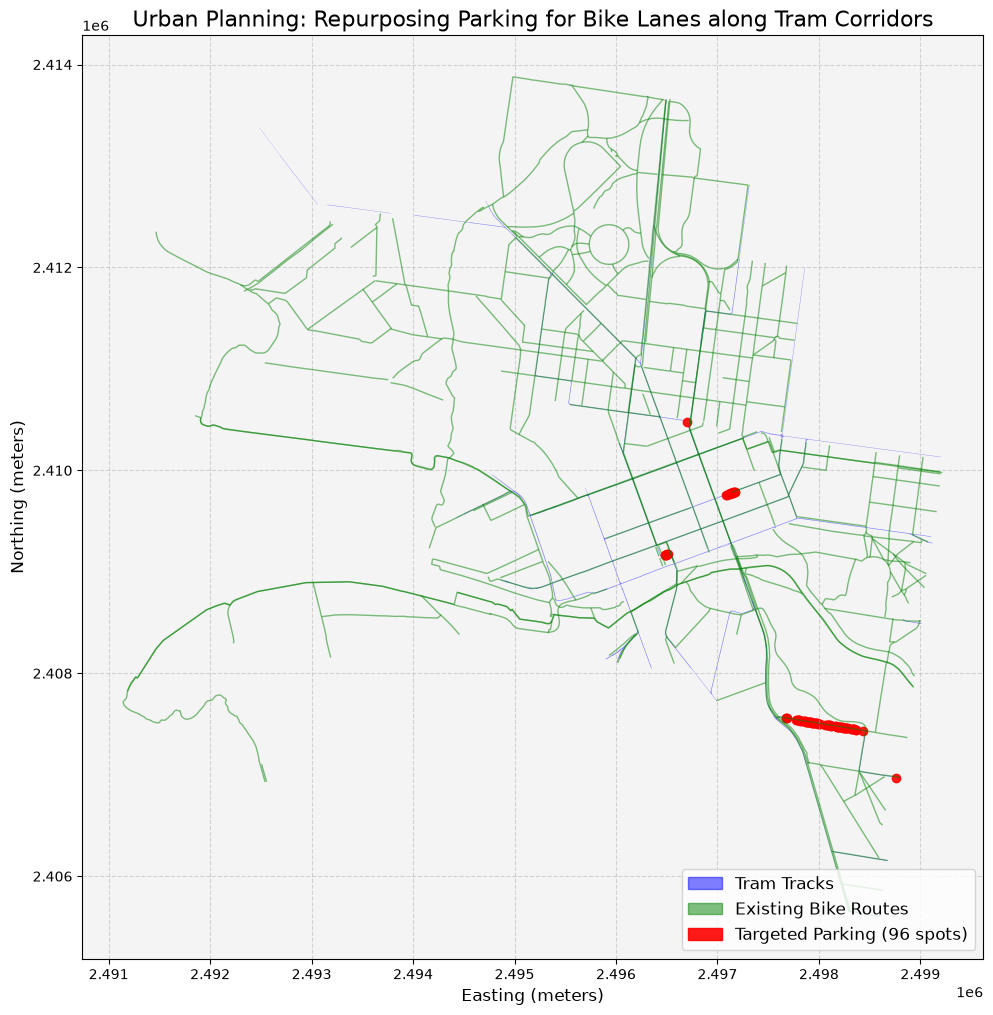

In [22]:
import matplotlib.patches as mpatches
print("Generating Visualization...")
fig, ax = plt.subplots(figsize=(14, 12))

# Plotting base layers (Set alpha for transparency so overlapping features are visible)
gdf_trams_metric.plot(ax=ax, color='blue', linewidth=1, alpha=0.5)
gdf_bikes.plot(ax=ax, color='green', linewidth=1, alpha=0.5)

# Plotting the targeted parking spots in bright red
impacted_parking.plot(ax=ax, color='red', alpha=0.9)

# Formatting the map
plt.title('Urban Planning: Repurposing Parking for Bike Lanes along Tram Corridors', fontsize=16)
plt.xlabel('Easting (meters)', fontsize=12)
plt.ylabel('Northing (meters)', fontsize=12)
ax.set_facecolor('#f4f4f4') # Light grey background
plt.grid(True, linestyle='--', alpha=0.5)

# Custom Legend
tram_patch = mpatches.Patch(color='blue', label='Tram Tracks', alpha=0.5)
bike_patch = mpatches.Patch(color='green', label='Existing Bike Routes', alpha=0.5)
park_patch = mpatches.Patch(color='red', label=f'Targeted Parking ({total_spots} spots)', alpha=0.9)
plt.legend(handles=[tram_patch, bike_patch, park_patch], loc='lower right', fontsize=12)

plt.savefig('compression_analysis_map.png', bbox_inches='tight', dpi=300)
plt.show()